# VAME-Style v4.0 手动训练接口

**内核要求**：`v3_recovery` venv 的 Python（torch 2.6 CUDA + vame 0.14.4 + hmmlearn）。
激活示例：`D:\KimiData\kimi\Workspaces\IMU\v3_recovery\venv\Scripts\python.exe -m ipykernel install --user --name=v3rec` 后在本 notebook 右上角选 `v3rec`。

**使用方式**：只在 **§1 参数面板** 改参数，然后按顺序运行 cell。
- §4 / §7 的绘图 cell 与训练解耦，可随时手动重跑；
- 训练中断后重跑 §3 的 cell 即自动断点续训；
- 每次运行的全部产物落在 `P["run_dir"]` 单一目录内：`checkpoints/ logs/ figures/ outputs/ vame_project/`；
- §2a 是**预处理入口**（npz → VAME 工程数据），当前默认读已存好的 25 Hz npz，改 `channels`/`rebuild` 可重建。


In [10]:
# ==== §0 环境与全局路径 ====
import sys, json, time, shutil
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

WORKSPACE = Path(r"D:\KimiData\kimi\Workspaces\IMU")
VAME_STYLE = WORKSPACE / "VAME-Style"
VAME_IMU = WORKSPACE / "VAME-IMU"
for p in (str(VAME_STYLE), str(VAME_IMU)):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
# vame 检查点含 ruamel 标量对象，torch 2.6 默认 weights_only=True 会拒载
_orig_load = torch.load
torch.load = lambda *a, **k: _orig_load(*a, **{**k, "weights_only": False})

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")     # 无头环境
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cuda


## §1 参数面板（唯一改参处）

每轮实验**只需改这里**：`run_dir` 换成新目录即隔离一次实验的全部产物。`dyn9` 通道为路线 A 预览（grav 经逐鼠垂直零点旋转），默认 `dyn6` 与现行定档一致。

In [11]:
# ==== §1 参数面板 ====
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '16')  # 静默 loky 物理核心探测警告（WinError 2，无害：仅回退用逻辑核心数）
from datetime import datetime

P = dict(
    # ---- 输出根目录：每次运行手填（默认按时间戳新建，可改成任意路径）----
    #run_dir=str(VAME_STYLE / "runs" / f"manual_{datetime.now():%Y%m%d_%H%M%S}"),
    run_dir=str(VAME_STYLE / "runs" / "manual_20260928_140939"),  # 手动指定
    data=dict(
        npz_dir=str(VAME_IMU / "data" / "ds25"),   # 已预处理 25 Hz npz（raw6/feat9/t/mask）
        sessions=["rec_000", "rec_001", "rec_002", "rec_003", "rec_004",
                  "rec_005", "rec_006", "rec_007", "rec_008", "rec_009",
                  "rec_010", "rec_011", "rec_012", "rec_013"],
        channels="dyn6",     # dyn6 = [acc3|gyro3] | dyn9 = [acc3|grav3(旋转)|gyro3]（实验性）
        test_fraction=0.1,   # mode_2 连续块切分的测试集占比
        rebuild=False,       # True = 强制重建 processed nc 与 train_seq
    ),

    vae=dict(
        max_epochs=80, epochs_per_block=4,   # 每 cell 运行一块，中断重跑即续
        batch_size=256, zdims=16,
        beta=1.0, kl_start=2, annealtime=4, anneal_function="linear",
        learning_rate=5e-4, scheduler_gamma=0.2, scheduler_step_size=100,
        time_window=30,      # 1.2 s @25 Hz；latent 长 = T-29
        prediction_steps=15, prediction_decoder=True,
        hidden_size_layer_1=256, hidden_size_layer_2=256,
        hidden_size_rec=256, hidden_size_pred=256,
        dropout_encoder=0.0, dropout_rec=0.0, dropout_pred=0.0, softplus=False,
    ),

    embed=dict(batch_size=256, run=True),

    hmm=dict(
        hand_version="12",   # 旁路特征：12 = 旧 grav3 三列 | "c" = θ/sinφ/cosφ/grav_std
        k_list=list(range(30, 41)), # BIC 逐个扫描 K=30..40（含端点，共 11 个）
        n_sub=100000, seed=0, n_iter=30,
        covariance_type="full", sticky=0.98,
        subset="v12",        # 排除 rec_011/013（安装角离群）
        decode=True,         # 扫完对 BIC 最优 K 做 sticky 解码出标签
    ),
)

def apply_params():
    """由 P 派生路径常量并创建目录层级（改 P 后重跑本函数即可）。"""
    global RUN_DIR, PROJ
    RUN_DIR = Path(P["run_dir"])
    PROJ = RUN_DIR / "vame_project"
    for sub in ["data", "checkpoints", "logs", "figures",
                "outputs/mu", "outputs/hmm", "vame_project"]:
        (RUN_DIR / sub).mkdir(parents=True, exist_ok=True)
    return RUN_DIR

apply_params()
print("RUN_DIR =", RUN_DIR)


RUN_DIR = D:\KimiData\kimi\Workspaces\IMU\VAME-Style\runs\manual_20260928_140939


## §2 数据准备（预处理入口）

§2a 把 25 Hz npz 写成 VAME 的 `processed nc`（逐 session robust-z；逻辑内联自 `vameimu.data`，口径一致）；§2b 用 VAME 原生 `create_trainset`（mode_2 连续块切分）生成 `train_seq/test_seq`。平时 `rebuild=False` 直接复用；换 `channels="dyn9"` 或改 npz 后置 `rebuild=True`。

In [ ]:
# ==== §2a npz → processed nc（预处理入口；内联自 vameimu.data）====
import xarray as xr


def _robust_z(x):
    """逐 session 逐列 robust-z（IQR 口径），与 vameimu.data.robust_z 同式。"""
    med = np.median(x, axis=0)
    q75, q25 = np.percentile(x, [75, 25], axis=0)
    scale = np.where(q75 - q25 > 1e-12, q75 - q25, 1.0)
    return ((x - med) / scale).astype(np.float32)


def _write_processed_nc(out_path, z, keypoints, fps=25.0):
    """(T,C) 标准化信号 → VAME processed nc（keypoints=C/3 × xyz）。"""
    T, C = z.shape
    assert C % 3 == 0 and C // 3 == len(keypoints), (C, keypoints)
    dims = ("time", "space", "keypoints", "individuals")
    vals = z.T.reshape(3, C // 3, T, 1).transpose(2, 0, 1, 3)  # (T,space,keypoints,1)
    ds = xr.Dataset(
        {"position": (dims, vals),
         "position_processed": (dims, vals),
         "confidence": (("time", "keypoints", "individuals"),
                        np.ones((T, len(keypoints), 1), dtype=np.float32))},
        coords={"time": np.arange(T, dtype=np.float64),
                "space": ["x", "y", "z"],
                "keypoints": list(keypoints),
                "individuals": ["mouse0"]},
        attrs={"fps": fps, "source_software": "vameimu-manual",
               "centered_reference_keypoint": "__none__",
               "orientation_reference_keypoint": "__none__"})
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ds.to_netcdf(str(out_path))


def _session_X(npz_path, channels):
    """取 VAME 输入矩阵：dyn6=raw6；dyn9=[raw_acc3 | R_s(grav) | gyro3]。"""
    d = np.load(npz_path)
    if channels == "dyn6":
        return d["raw6"].astype(np.float64), ["linacc", "gyro"]
    from vamestyle.posture import _align_rotation
    acc = d["raw6"][:, 0:3].astype(np.float64)
    gyro = d["raw6"][:, 3:6].astype(np.float64)
    grav = d["feat9"][:, 3:6].astype(np.float64)
    R = _align_rotation(np.median(grav, axis=0))   # 逐鼠垂直零点
    return np.concatenate([acc, grav @ R.T, gyro], axis=1), ["linacc", "grav", "gyro"]


def build_processed(P):
    npz_dir = Path(P["data"]["npz_dir"])
    outdir = PROJ / "data" / "processed"
    for s in P["data"]["sessions"]:
        dst = outdir / f"{s}_processed.nc"
        if dst.exists() and not P["data"]["rebuild"]:
            print(f"[data] {s}: nc 已存在，跳过")
            continue
        X, kps = _session_X(npz_dir / f"{s}.npz", P["data"]["channels"])
        z = _robust_z(X)
        _write_processed_nc(dst, z, kps)
        print(f"[data] {s}: processed.nc {z.shape} keypoints={kps}")

    need_seq = not (PROJ / "data" / "train" / "train_seq.npy").exists() \
        or P["data"]["rebuild"]
    if need_seq:
        from vame.model.create_training import create_trainset as vame_create_trainset
        vame_create_trainset(cfg, test_fraction=P["data"]["test_fraction"],
                             split_mode="mode_2")
        print("[data] train/test 序列已生成（mode_2 连续块切分）")
    else:
        print("[data] 训练序列已存在，跳过（rebuild=True 强制重建）")


In [ ]:
# ==== §2b VAME 工程骨架 + 执行数据准备 ====
from vame.schemas.project import ProjectSchema
from vame.schemas.states import VAMEPipelineStatesSchema
from vame.util.auxiliary import write_config


def build_project_cfg(P):
    """按参数面板组装 VAME 工程 config（schema 默认 + 面板覆盖）。"""
    v = P["vae"]
    n_kp = 3 if P["data"]["channels"] == "dyn9" else 2
    cfg = ProjectSchema(
        vame_version="0.14.4",
        project_name=PROJ.name,
        project_path=str(PROJ),
        session_names=list(P["data"]["sessions"]),
        pose_estimation_filetype="nc",
        all_data="Yes",
        keypoints=(["linacc", "grav", "gyro"] if n_kp == 3 else ["linacc", "gyro"]),
        egocentric_data=False,
        test_fraction=P["data"]["test_fraction"],
        model_name="VAME",
        pretrained_model="None",
        pretrained_weights=False,
        num_features=3 * n_kp,
        batch_size=v["batch_size"],
        max_epochs=v["max_epochs"],
        transition_function="GRU",
        beta=v["beta"],
        beta_norm=False,
        zdims=v["zdims"],
        learning_rate=v["learning_rate"],
        time_window=v["time_window"],
        prediction_decoder=v["prediction_decoder"],
        prediction_steps=v["prediction_steps"],
        noise=False,
        scheduler=1,
        scheduler_step_size=v["scheduler_step_size"],
        scheduler_gamma=v["scheduler_gamma"],
        steps_per_epoch=None,
        n_clusters=max(P["hmm"]["k_list"]),
        segmentation_algorithms=["hmm"],
        hmm_n_iter=P["hmm"]["n_iter"],
        individual_segmentation=False,
        length_of_motif_video=1000,
        project_random_state=42,
    ).model_dump()
    # 面板覆盖（schema 默认之外的训练超参）
    for k in ("kl_start", "annealtime", "anneal_function",
              "hidden_size_layer_1", "hidden_size_layer_2",
              "hidden_size_rec", "hidden_size_pred",
              "dropout_encoder", "dropout_rec", "dropout_pred", "softplus"):
        cfg[k] = v[k]
    write_config(str(PROJ / "config.yaml"), cfg)
    (PROJ / "states").mkdir(parents=True, exist_ok=True)
    (PROJ / "states" / "states.json").write_text(
        VAMEPipelineStatesSchema().model_dump_json(indent=2), encoding="utf-8")
    return cfg


cfg = build_project_cfg(P)
print("工程骨架 ->", PROJ)
build_processed(P)


## §3 VAE 训练（VAME，断点续跑）

每运行一次 cell 训练 `epochs_per_block` 轮，直至 `max_epochs`。中断/改参数后重跑本 cell 自动续接（状态在 `RUN_DIR/vame_project/model/chunk_state.pkl`）。逐 epoch 指标实时追加到 `logs/train_log.jsonl` 并同时留在工程 `model/chunk_metrics.jsonl`。

In [ ]:
# ==== §3 VAE 训练（反复运行本 cell 直至 TRAINING_DONE）====
from vameimu.trainer import train_chunk

t0 = time.time()
total = P["vae"]["max_epochs"]
while True:
    done = train_chunk(cfg, total_epochs=total,
                       chunk_epochs=P["vae"]["epochs_per_block"])
    if done >= total:
        break
shutil.copyfile(PROJ / "model" / "chunk_metrics.jsonl",
                RUN_DIR / "logs" / "train_log.jsonl")

# 训练结束自动生成完成日志（要求 5）
import json as _json
last = _json.loads(open(RUN_DIR / "logs" / "train_log.jsonl", encoding="utf-8").readlines()[-1])
with open(RUN_DIR / "logs" / "training_done.txt", "w", encoding="utf-8") as f:
    f.write(f"VAE 训练完成\nepochs={total}\n最后指标={last}\n"
            f"耗时={time.time() - t0:.0f}s\ndevice={DEVICE}\n")
shutil.copytree(PROJ / "model" / "best_model" / "snapshots",
                RUN_DIR / "checkpoints" / "snapshots", dirs_exist_ok=True)
print(f"TRAINING_DONE  耗时 {time.time() - t0:.0f}s；"
      f"日志 {RUN_DIR / 'logs' / 'training_done.txt'}")


## §4 训练曲线（cell 输出绘制）

从 `logs/train_log.jsonl` 读取，训练中途也能手动运行看进度。

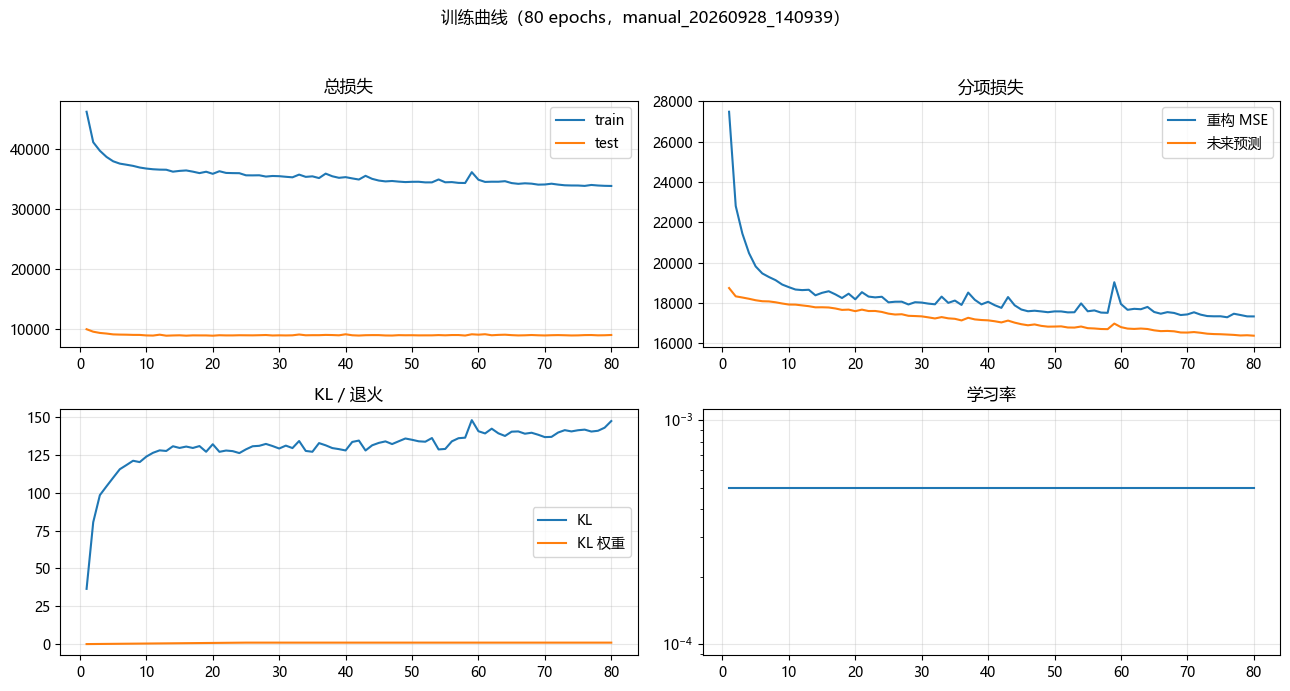

In [12]:
# ==== §4 训练曲线 ====
def load_train_log():
    p = RUN_DIR / "logs" / "train_log.jsonl"
    if not p.exists():          # 兼容：直接从工程读
        p = PROJ / "model" / "chunk_metrics.jsonl"
    return [json.loads(l) for l in open(p, encoding="utf-8")] if p.exists() else []


def plot_training_curves():
    m = load_train_log()
    if not m:
        print("暂无训练记录，先运行 §3")
        return
    ep = [r["epoch"] for r in m]
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    ax = axes[0, 0]
    ax.plot(ep, [r["train_loss"] for r in m], label="train")
    ax.plot(ep, [r["test_loss"] for r in m], label="test")
    ax.set_title("总损失"); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[0, 1]
    ax.plot(ep, [r["mse"] for r in m], label="重构 MSE")
    ax.plot(ep, [r["fut"] for r in m], label="未来预测")
    ax.set_title("分项损失"); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1, 0]
    ax.plot(ep, [r["kl"] for r in m], label="KL")
    ax.plot(ep, [r["kl_w"] for r in m], label="KL 权重")
    ax.set_title("KL / 退火"); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1, 1]
    ax.plot(ep, [r["lr"] for r in m])
    ax.set_title("学习率"); ax.set_yscale("log"); ax.grid(alpha=0.3)
    fig.suptitle(f"训练曲线（{len(m)} epochs，{RUN_DIR.name}）")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(RUN_DIR / "figures" / "training_curves.png", dpi=120)
    plt.show()

plot_training_curves()


## §5 embed：mu latent

用训练好的 best_model 全量编码 → `outputs/mu/mu_<session>.npy`（下游 HMM 用）。`run=False` 时直接读已存 mu。

In [13]:
# ==== §5 embed ====
if P["embed"]["run"]:
    from vameimu.vame_pipeline import embed as vame_embed
    lat = vame_embed(cfg, batch_size=P["embed"]["batch_size"])
    for s, mu in lat.items():
        np.save(RUN_DIR / "outputs" / "mu" / f"mu_{s}.npy",
                np.asarray(mu, dtype=np.float32))
else:
    print("embed.run=False，读取已存 mu")

MU = {s: np.load(RUN_DIR / "outputs" / "mu" / f"mu_{s}.npy")
      for s in P["data"]["sessions"]
      if (RUN_DIR / "outputs" / "mu" / f"mu_{s}.npy").exists()}
assert MU, "mu 为空：先运行 embed（embed.run=True）"
for s, mu in MU.items():
    assert mu.shape[1] == P["vae"]["zdims"], (s, mu.shape)
print({s: tuple(v.shape) for s, v in MU.items()})


NameError: name 'cfg' is not defined

## §6 HMM：BIC 曲线 + sticky 解码

zfeat = [mu(16) ‖ 旁路 hand（12 或 13，按 `hand_version`）]，逐 session robust-z 后拼接；`subset="v12"` 时拟合池排除 rec_011/013。对每个 K 做 full-cov EM，**BIC/ICL 曲线 cell 内绘制**；`decode=True` 时对 BIC 最优 K 全量 sticky 解码，标签/使用率落 `outputs/hmm/`。

In [6]:
# ==== §6a 构建本次运行 zfeat（mu 用刚训出的，不用旧缓存）====
import joblib
from vamestyle.dataset import Session
from vamestyle.features import (hand_features, hand_features_c,
                                _robust_z as _hand_robust_z)


def build_run_zfeat(P):
    names = list(P["data"]["sessions"])
    if P["hmm"]["subset"] == "v12":
        from vamestyle.dataset import CFG as _CFG
        ex = set(_CFG["data"].get("exclude", []))
        names = [n for n in names if n not in ex]
    zf = {}
    for n in names:
        mu = MU[n]
        sess = Session(n)          # 读 25 Hz npz（feat9 供旁路特征）
        if P["hmm"]["hand_version"] == "c":
            _, hand = hand_features_c(sess)
        else:
            _, hand = hand_features(sess)
        C = P["vae"]["time_window"] // 2
        hand = hand[C:sess.T - C + 1]
        assert len(hand) == len(mu), (n, len(hand), len(mu))
        zf[n] = np.concatenate([mu, _hand_robust_z(hand)], axis=1)
    return zf, names


ZRUN, names_run = build_run_zfeat(P)
X = np.concatenate([ZRUN[n] for n in names_run], axis=0)
rng = np.random.default_rng(P["hmm"]["seed"])
i0 = int(rng.integers(0, X.shape[0] - P["hmm"]["n_sub"]))
blk = X[i0:i0 + P["hmm"]["n_sub"]]
print(f"拟合块 {blk.shape}（seed={P['hmm']['seed']} 连续帧 @{i0}）")


NameError: name 'MU' is not defined

In [ ]:
# ==== §6b BIC 扫描（EM 全收敛后自动绘图；改 k_list 后重跑本 cell）====
from hmmlearn.hmm import GaussianHMM


def _n_params(K, D):
    return (K - 1) + K * (K - 1) + K * D + K * D * (D + 1) // 2


hmm_fit = {}
for K in P["hmm"]["k_list"]:
    m = GaussianHMM(n_components=K,
                    covariance_type=P["hmm"]["covariance_type"],
                    n_iter=P["hmm"]["n_iter"], random_state=P["hmm"]["seed"])
    m.fit(blk)
    ll = m.score(blk)
    bic = -2 * ll + _n_params(K, blk.shape[1]) * np.log(len(blk))
    post = m.predict_proba(blk)
    with np.errstate(divide="ignore", invalid="ignore"):
        lp = np.log(post)
    lp[~np.isfinite(lp)] = 0.0
    icl = bic - 2 * (post * lp).sum()
    hmm_fit[K] = dict(model=m, loglik=ll, bic=float(bic), icl=float(icl),
                      converged=bool(m.monitor_.converged))
    joblib.dump({"K": K, "model": m, "bic": float(bic), "icl": float(icl),
                 "loglik": float(ll), "params": {k: v for k, v in P["hmm"].items()}},
                RUN_DIR / "outputs" / "hmm" / f"hmm_k{K}.joblib")
    print(f"[hmm] K={K}: BIC={bic:.0f} ICL={icl:.0f} conv={m.monitor_.converged}")
print("模型 ->", RUN_DIR / "outputs" / "hmm")


In [ ]:
# ==== §6c BIC / ICL 曲线（cell 输出绘制，可反复运行）====
def plot_bic_curves():
    if not hmm_fit:
        print("先运行 §6b")
        return
    Ks = sorted(hmm_fit)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, key, name in ((axes[0], "bic", "BIC"), (axes[1], "icl", "ICL")):
        ys = [hmm_fit[k][key] for k in Ks]
        ax.plot(Ks, ys, "o-")
        kb = Ks[int(np.argmin(ys))]
        ax.axvline(kb, color="r", ls="--", alpha=0.5)
        ax.set_title(f"{name}（最优 K={kb}）")
        ax.set_xlabel("K"); ax.grid(alpha=0.3)
    fig.suptitle(f"HMM 模型选择（{RUN_DIR.name}）")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(RUN_DIR / "figures" / "bic_curves.png", dpi=120)
    plt.show()

plot_bic_curves()


In [ ]:
# ==== §6d sticky 解码（BIC 最优 K，全量 12/14 条）====
from vamestyle.states import sticky_decode as _sticky

if P["hmm"]["decode"]:
    K_best = min(hmm_fit, key=lambda k: hmm_fit[k]["bic"])
    model = hmm_fit[K_best]["model"]
    usage = np.zeros(K_best, dtype=np.int64)
    for n in names_run:
        lab = _sticky(model, ZRUN[n], kappa=P["hmm"]["sticky"]).astype(np.int16)
        np.save(RUN_DIR / "outputs" / "hmm" / f"labels_k{K_best}_{n}.npy", lab)
        usage += np.bincount(lab, minlength=K_best)
    pct = 100 * usage / usage.sum()
    with open(RUN_DIR / "outputs" / "hmm" / f"usage_k{K_best}.csv", "w",
              newline="", encoding="utf-8") as f:
        import csv as _csv
        w = _csv.writer(f); w.writerow(["state", "pct"])
        for i in np.argsort(-pct):
            w.writerow([int(i), round(float(pct[i]), 3)])
    print(f"[decode] K={K_best}：K_eff(≥1%)={(pct >= 1).sum()}  "
          f"最大类 {pct.max():.1f}%（红线 <10%） 标签 -> outputs/hmm/")
else:
    print("hmm.decode=False，跳过解码")


## §7 手动验证绘图（与训练解耦，可反复运行）

7a 训练曲线重绘 / 7b 重构样本抽查 / 7c latent 流形 / 7d 能量回归 sanity / 7e 姿态桶熵。全部图另存 `RUN_DIR/figures/`。

In [ ]:
# ==== §7a 训练曲线（独立重绘）====
plot_training_curves()


In [ ]:
# ==== §7b 重构样本抽查 ====
from vame.model.rnn_vae import RNN_VAE


def plot_reconstruction_check(n_win=4):
    v = P["vae"]
    model = RNN_VAE(v["time_window"] * 2, v["zdims"], cfg["num_features"],
                    v["prediction_decoder"], v["prediction_steps"],
                    cfg["hidden_size_layer_1"], cfg["hidden_size_layer_2"],
                    cfg["hidden_size_rec"], cfg["hidden_size_pred"],
                    cfg["dropout_encoder"], cfg["dropout_rec"],
                    cfg["dropout_pred"], cfg["softplus"]).to(DEVICE)
    best_p = PROJ / "model" / "best_model" / f"{cfg['model_name']}_{cfg['project_name']}.pkl"
    model.load_state_dict(torch.load(best_p, map_location=DEVICE))
    model.eval()

    td = PROJ / "data" / "train"
    Xte = np.load(td / "test_seq.npy")
    if Xte.shape[0] > Xte.shape[1]:
        Xte = Xte.T
    mean = float(np.load(td / "seq_mean.npy"))
    std = float(np.load(td / "seq_std.npy"))
    Xte = ((Xte - mean) / std).astype(np.float32)

    rng = np.random.default_rng(0)
    half = v["time_window"]
    kps = cfg["keypoints"]
    fig, axes = plt.subplots(n_win, cfg["num_features"],
                             figsize=(2.0 * cfg["num_features"], 1.8 * n_win))
    for r in range(n_win):
        s0 = int(rng.integers(0, Xte.shape[1] - half))
        win = torch.from_numpy(Xte[:, s0:s0 + half]).T.unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            out = model(win)
        rec = out[0][0, :, :].cpu().numpy()
        raw = win[0].cpu().numpy()
        for ch in range(cfg["num_features"]):
            ax = axes[r, ch] if n_win > 1 else axes[ch]
            ax.plot(raw[:, ch], lw=0.8, label="输入")
            ax.plot(rec[:, ch], lw=0.8, ls="--", label="重构")
            ax.set_ylim(-4, 4); ax.tick_params(labelsize=6)
            if r == 0:
                ax.set_title(f"{kps[ch // 3]}{'xyz'[ch % 3]}", fontsize=8)
    axes[0, 0].legend(fontsize=7)
    fig.suptitle("重构样本抽查（实线=输入，虚线=重构）")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(RUN_DIR / "figures" / "reconstruction_check.png", dpi=120)
    plt.show()

plot_reconstruction_check()


In [ ]:
# ==== §7c latent 流形（PCA 着色 = log 能量）====
from sklearn.decomposition import PCA


def plot_latent_manifold():
    mus, es = [], []
    for n in names_run:
        mus.append(MU[n])
        sess = Session(n)
        _, hand = (hand_features_c(sess) if P["hmm"]["hand_version"] == "c"
                   else hand_features(sess))
        C = P["vae"]["time_window"] // 2
        es.append(hand[C:sess.T - C + 1, 0])      # 第 0 列 = log 能量
    M = np.concatenate(mus); E = np.concatenate(es)
    assert len(M) == len(E)
    Z = PCA(n_components=2, random_state=0).fit_transform(M[::10])
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=E[::10], s=2, cmap="viridis")
    fig.colorbar(sc, label="log10 能量")
    ax.set_title(f"mu 流形 PCA（{len(M)} 帧，着色=能量）")
    fig.tight_layout()
    fig.savefig(RUN_DIR / "figures" / "latent_manifold.png", dpi=120)
    plt.show()

plot_latent_manifold()


In [ ]:
# ==== §7d 能量回归 sanity（mu → log 能量 R²）====
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


def energy_regression_sanity():
    mus, es = [], []
    for n in names_run:
        mus.append(MU[n])
        sess = Session(n)
        _, hand = (hand_features_c(sess) if P["hmm"]["hand_version"] == "c"
                   else hand_features(sess))
        C = P["vae"]["time_window"] // 2
        es.append(hand[C:sess.T - C + 1, 0])
    M = np.concatenate(mus); E = np.concatenate(es)
    r2 = cross_val_score(LinearRegression(), M[::5], E[::5], cv=5,
                         scoring="r2")
    print(f"mu→能量 线性回归 R²（5 折）：{r2.mean():.3f} ± {r2.std():.3f}"
          f"（现行管线口径 0.437 作对照）")

energy_regression_sanity()


In [ ]:
# ==== §7e 姿态桶熵（解码标签的每状态姿态纯度；需先跑 §6d）====
from sklearn.cluster import KMeans
from vamestyle.posture import _align_rotation, V0


def posture_entropy_check(kb=4):
    labs = {n: np.load(RUN_DIR / "outputs" / "hmm" / f)
            for n in names_run
            for f in [next((RUN_DIR / "outputs" / "hmm").glob(f"labels_k*_{n}.npy"), None)]
            if f is not None}
    if not labs:
        print("无解码标签，先运行 §6d（hmm.decode=True）")
        return
    C = P["vae"]["time_window"] // 2
    gmeans, states = [], []
    for n, lab in labs.items():
        sess = Session(n)
        grav = sess.grav[C:C + len(lab)].astype(np.float64)
        R = _align_rotation(np.median(sess.grav, axis=0))
        grav_r = grav @ R.T
        d = np.diff(lab)
        starts = np.concatenate([[0], np.nonzero(d)[0] + 1])
        ends = np.concatenate([starts[1:], [len(lab)]])
        for a, b in zip(starts, ends):
            if b - a < 4:
                continue
            gmeans.append(grav_r[a:b].mean(0) - V0)
            states.append(int(lab[a]))
    G = np.array(gmeans); states = np.array(states)
    bk = KMeans(n_clusters=kb, n_init=10, random_state=0).fit_predict(G)
    ent = []
    for st in np.unique(states):
        p = np.bincount(bk[states == st], minlength=kb).astype(float)
        p /= p.sum()
        p = p[p > 0]
        ent.append(-(p * np.log(p)).sum() / np.log(kb))
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.bar(np.unique(states), ent, color="steelblue")
    ax.axhline(np.mean(ent), color="r", ls="--", label=f"均值 {np.mean(ent):.3f}")
    ax.set_xlabel("状态"); ax.set_ylabel("姿态桶归一化熵（1=最混）")
    ax.set_title(f"每状态姿态桶熵（kb={kb}，越低越纯）"); ax.legend()
    fig.tight_layout()
    fig.savefig(RUN_DIR / "figures" / "posture_entropy.png", dpi=120)
    plt.show()
    print(f"桶熵均值 {np.mean(ent):.3f}（现行管线旧口径 0.665 作对照）")

posture_entropy_check()


## §8 日志汇总（每次实验结束运行一次）

生成 `config_snapshot.json`（全部参数快照）与 `train_summary.txt`（实验结论 + 最终指标 + 文件清单），连同逐 epoch 明细构成完整训练日志。

In [ ]:
# ==== §8 日志汇总 ====
hmm_fit = globals().get("hmm_fit", {})   # 未跑 §6 时为空
summary = {}
summary["run_dir"] = str(RUN_DIR)
summary["time"] = time.strftime("%Y-%m-%d %H:%M:%S")
summary["device"] = DEVICE
summary["params"] = P

# 训练最终指标
m = load_train_log()
if m:
    summary["final_epoch_metrics"] = m[-1]
    summary["n_epochs"] = len(m)

# HMM 结果
if hmm_fit:
    summary["hmm"] = {str(k): {kk: vv for kk, vv in v.items() if kk != "model"}
                      for k, v in hmm_fit.items()}

json.dump(P, open(RUN_DIR / "config_snapshot.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

lines = [f"VAME-Style 手动训练实验日志  {summary['time']}",
         f"RUN_DIR: {RUN_DIR}", f"device : {DEVICE}", "",
         "== 参数快照 ==", json.dumps(P, ensure_ascii=False, indent=2), ""]
if m:
    lines += ["== VAE 最终指标（末 epoch）==", json.dumps(m[-1], ensure_ascii=False), ""]
if hmm_fit:
    lines += ["== HMM BIC 扫描 =="]
    for k in sorted(hmm_fit):
        v = hmm_fit[k]
        lines.append(f"  K={k}: BIC={v['bic']:.0f} ICL={v['icl']:.0f} conv={v['converged']}")
    lines.append("")
lines.append("== 文件清单 ==")
for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file():
        lines.append(f"  {p.relative_to(RUN_DIR)}  ({p.stat().st_size // 1024} KB)")
(RUN_DIR / "train_summary.txt").write_text("\n".join(lines), encoding="utf-8")
print(f"日志已生成：{RUN_DIR / 'train_summary.txt'}")
print("\n".join(lines[-20:]))
